# Selección del modelo

In [1]:
# Cargando las librerias necesarias
import pickle
import pandas as pd
import numpy as np
import joblib
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, RandomizedSearchCV, HalvingRandomSearchCV, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, make_scorer, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import StackingClassifier, VotingClassifier, RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_selection import RFE, SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone

# Customizaciones
pd.set_option('display.max_columns', None)

In [2]:
# Cargando los datos de la fase anterior de limpieza desde un fichero pickle
df = pd.read_pickle('./data/df_trans.pkl')

# Verificar el dataframe
print(df.head())
print(df.info())
print(df.shape)

   Diabetes_binary  HighBP  HighChol  CholCheck       BMI  Smoker  Stroke  \
0              0.0     1.0       0.0        1.0 -0.602885     0.0     0.0   
1              0.0     1.0       1.0        1.0 -0.602885     1.0     1.0   
2              0.0     0.0       0.0        1.0 -0.602885     0.0     0.0   
3              0.0     1.0       1.0        1.0 -0.281138     1.0     0.0   
4              0.0     0.0       0.0        1.0 -0.120264     1.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  Veggies  HvyAlcoholConsump  \
0                   0.0           1.0     0.0      1.0                0.0   
1                   0.0           0.0     1.0      0.0                0.0   
2                   0.0           1.0     1.0      1.0                0.0   
3                   0.0           1.0     1.0      1.0                0.0   
4                   0.0           1.0     1.0      1.0                0.0   

   AnyHealthcare  NoDocbcCost   GenHlth  MentHlth  PhysHlth  DiffWalk  Sex

## Selección de variables para reducir el input de los usuarios

In [3]:
X = df.drop(columns=["Diabetes_binary"])
y = df["Diabetes_binary"].astype(int)

# 1. Random Forest Feature Importance
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X, y)
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("=== Importancia de variables (Random Forest) ===")
print(importancias)

# 2. Logistic Regression con L1 (Lasso)
log_l1 = LogisticRegression(penalty="l1", solver="liblinear", random_state=42)
log_l1.fit(X, y)
coefs = pd.Series(np.abs(log_l1.coef_[0]), index=X.columns).sort_values(ascending=False)

print("\n=== Importancia de variables (Logistic L1) ===")
print(coefs)

# 3. Selección de top 10 por RF
top10_rf = importancias.head(10).index.tolist()
# 4. Selección de top 10 por L1
top10_l1 = coefs.head(10).index.tolist()

# Intersección como "más estables"
selecionadas_RF_L1 = list(set(top10_rf) & set(top10_l1))

print("\nVariables recomendadas (intersección RF + L1):", selecionadas_RF_L1)

=== Importancia de variables (Random Forest) ===
BMI                     0.167995
Age                     0.129305
GenHlth                 0.105050
Income                  0.085049
HighBP                  0.071779
PhysHlth                0.070074
Education               0.058685
MentHlth                0.053002
HighChol                0.039140
Fruits                  0.029242
Smoker                  0.029170
Sex                     0.026457
DiffWalk                0.024584
PhysActivity            0.023454
Veggies                 0.022495
HeartDiseaseorAttack    0.018933
NoDocbcCost             0.012244
Stroke                  0.010073
HvyAlcoholConsump       0.009432
AnyHealthcare           0.007712
CholCheck               0.006126
dtype: float64

=== Importancia de variables (Logistic L1) ===
CholCheck               1.312852
HvyAlcoholConsump       0.745138
HighBP                  0.696554
GenHlth                 0.627027
HighChol                0.571138
BMI                     0.5406

In [4]:
target = "Diabetes_binary"
X = df.drop(columns=[target])
y = df[target].astype(int)

# Escalado 0-1 SOLO para la selección (no modifica df)
X_nonneg = MinMaxScaler().fit_transform(X)

selector = SelectKBest(score_func=chi2, k=10)
selector.fit(X_nonneg, y)

selecionadas_KBest = X.columns[selector.get_support()].tolist()
print("Variables seleccionadas (chi²):", selecionadas_KBest)

Variables seleccionadas (chi²): ['HighBP', 'HighChol', 'BMI', 'Stroke', 'HeartDiseaseorAttack', 'HvyAlcoholConsump', 'GenHlth', 'PhysHlth', 'DiffWalk', 'Age']


## Hacer el split entre train y test

In [5]:
# Separar variables predictoras (X) y objetivo (y)
# Variables seleccionadas
# vars_seleccionadas = selecionadas_RF_L1
vars_seleccionadas = selecionadas_KBest
target = 'Diabetes_binary'

# Definir X e y solo con las variables seleccionadas
# X = df[vars_seleccionadas]
X = df.drop(columns=[target])
y = df[target].astype(int)

# Split en train y test (80/20) – sin estratificación (como indicaste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,stratify=y, random_state=99
)

print("Shape train:", X_train.shape, "Shape test:", X_test.shape)
print("\nDistribución target en train:\n", y_train.value_counts(normalize=True).round(3))
print("\nDistribución target en test:\n", y_test.value_counts(normalize=True).round(3))

Shape train: (54174, 21) Shape test: (13544, 21)

Distribución target en train:
 Diabetes_binary
1    0.508
0    0.492
Name: proportion, dtype: float64

Distribución target en test:
 Diabetes_binary
1    0.508
0    0.492
Name: proportion, dtype: float64


## Por Cross validation

In [6]:
# Separar variables predictoras (X) y objetivo (y)
# Variables seleccionadas
# vars_seleccionadas = selecionadas_RF_L1
vars_seleccionadas = selecionadas_KBest
target = 'Diabetes_binary'

# Definir X e y solo con las variables seleccionadas
# X = df[vars_seleccionadas].copy()
X = df.drop(columns=[target])  
y = df[target].astype(int)
print("X shape:", X.shape, "| y shape:", y.shape)

X shape: (67718, 21) | y shape: (67718,)


## Preparar un pipeline para entrenar los modelos candidatos

In [7]:
# Definir pipelines de los modelos

pipelines = {
    "LogReg": Pipeline(steps=[
        ("model", LogisticRegression(max_iter=200, solver="lbfgs"))
    ]),
    "SVM-RBF": Pipeline(steps=[
        ("model", SVC(kernel="rbf", probability=True, random_state=42))  # datos ya escalados
    ]),
    "SVM-Linear": Pipeline(steps=[
        ("model", LinearSVC(random_state=42, max_iter=5000))
    ]),
    "RF": Pipeline(steps=[
        ("model", RandomForestClassifier(n_estimators=300, random_state=42))
    ]),
    "GB": Pipeline(steps=[
        ("model", GradientBoostingClassifier(random_state=42))
    ]),
      "HistGB": Pipeline(steps=[
        ("model", HistGradientBoostingClassifier(random_state=42))
    ]),
    "ExtraTrees": Pipeline(steps=[
        ("model", ExtraTreesClassifier(n_estimators=400, random_state=42))
    ]),
    # Lineales adicionales
    "SVM-Linear-Cal": Pipeline(steps=[
        ("model", CalibratedClassifierCV(LinearSVC(random_state=42, max_iter=5000), cv=5))
    ]),
    "SGD-Log": Pipeline(steps=[
        ("model", SGDClassifier(loss="log_loss", alpha=1e-4, max_iter=2000, random_state=42))
    ]),
    "LogReg-Bal": Pipeline(steps=[
        ("model", LogisticRegression(max_iter=500, solver="lbfgs", class_weight="balanced"))
    ]),
}

### Funciones para entrenar y evaluar los modelos

In [8]:
def _estimator_name(model):
    # Si es Pipeline, toma la clase del último step; si no, la clase del propio objeto
    if hasattr(model, "named_steps") and model.named_steps:
        return list(model.named_steps.values())[-1].__class__.__name__
    return model.__class__.__name__

def _scores_continuos(model, X):
    # Usa los métodos del objeto completo (pipeline o ensemble) para mantener las transformaciones
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return None

def evaluar_modelo_split(nombre, model, Xtr, ytr, Xte, yte, average="binary", show_report=True):
    model.fit(Xtr, ytr)
    y_pred  = model.predict(Xte)
    y_score = _scores_continuos(model, Xte)

    acc  = accuracy_score(yte, y_pred)
    prec = precision_score(yte, y_pred, average=average, zero_division=0)
    rec  = recall_score(yte, y_pred, average=average, zero_division=0)
    f1   = f1_score(yte, y_pred, average=average, zero_division=0)
    auc  = roc_auc_score(yte, y_score) if y_score is not None else np.nan
    ap   = average_precision_score(yte, y_score) if y_score is not None else np.nan

    if show_report:
        print(f"\n=== {nombre} ({_estimator_name(model)}) ===")
        print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | ROC-AUC: {auc:.4f} | PR-AUC: {ap:.4f}")
        print(classification_report(yte, y_pred, digits=4))

    return {
        "Modelo": nombre,
        "EstimatorClass": _estimator_name(model),
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": auc,
        "AvgPrecision(PR-AUC)": ap
    }

def evaluar_modelo_cv(nombre, model, X, y, cv_splits=5, stratified=True, average="binary", show_reports=True):
    splitter = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42).split(X, y) \
               if stratified else KFold(n_splits=cv_splits, shuffle=True, random_state=42).split(X)

    registros = []
    for fold, (idx_tr, idx_te) in enumerate(splitter, start=1):
        X_tr, X_te = X.iloc[idx_tr], X.iloc[idx_te]
        y_tr, y_te = y.iloc[idx_tr], y.iloc[idx_te]

        model.fit(X_tr, y_tr)
        y_pred  = model.predict(X_te)
        y_score = _scores_continuos(model, X_te)

        if show_reports:
            print(f"\n===== {nombre} | Fold {fold}/{cv_splits} ({_estimator_name(model)}) =====")
            print(classification_report(y_te, y_pred, digits=4))

        acc  = accuracy_score(y_te, y_pred)
        prec = precision_score(y_te, y_pred, average=average, zero_division=0)
        rec  = recall_score(y_te, y_pred, average=average, zero_division=0)
        f1   = f1_score(y_te, y_pred, average=average, zero_division=0)
        auc  = roc_auc_score(y_te, y_score) if y_score is not None else np.nan
        ap   = average_precision_score(y_te, y_score) if y_score is not None else np.nan

        registros.append({
            "fold": fold, "accuracy": acc, "precision": prec, "recall": rec,
            "f1": f1, "roc_auc": auc, "avg_precision": ap
        })

    df_cv = pd.DataFrame(registros)
    resumen = df_cv.mean(numeric_only=True).to_dict()
    if show_reports:
        print("\n===== Resumen CV (promedios) =====")
        print(pd.Series(resumen).round(4))
    return resumen, df_cv

## Entrenar y evaluar los modelos


=== LogReg (LogisticRegression) ===
Accuracy: 0.7400 | Precision: 0.7343 | Recall: 0.7652 | F1: 0.7494 | ROC-AUC: 0.8174 | PR-AUC: 0.7976
              precision    recall  f1-score   support

           0     0.7464    0.7140    0.7299      6662
           1     0.7343    0.7652    0.7494      6882

    accuracy                         0.7400     13544
   macro avg     0.7404    0.7396    0.7397     13544
weighted avg     0.7403    0.7400    0.7398     13544


=== SVM-RBF (SVC) ===
Accuracy: 0.7426 | Precision: 0.7209 | Recall: 0.8053 | F1: 0.7607 | ROC-AUC: 0.8089 | PR-AUC: 0.7680
              precision    recall  f1-score   support

           0     0.7712    0.6779    0.7215      6662
           1     0.7209    0.8053    0.7607      6882

    accuracy                         0.7426     13544
   macro avg     0.7460    0.7416    0.7411     13544
weighted avg     0.7456    0.7426    0.7414     13544


=== SVM-Linear (LinearSVC) ===
Accuracy: 0.7399 | Precision: 0.7315 | Recall: 0.7

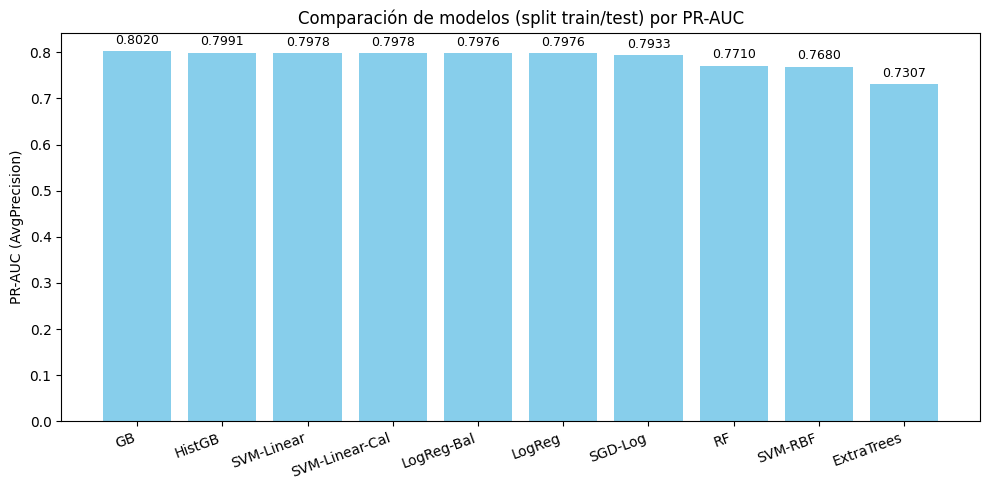

In [9]:
# === 1) Entrenamiento y evaluación por split train/test ===
resultados_split = []
modelos_entrenados = {}

for nombre, pipe in pipelines.items():
    # Entrenamos explícitamente
    pipe.fit(X_train, y_train)
    modelos_entrenados[nombre] = pipe

    # Evaluación
    m = evaluar_modelo_split(
        nombre, pipe,
        X_train, y_train,
        X_test, y_test,
        average="binary"
    )
    resultados_split.append(m)

# === 2) Ranking según PR-AUC primero, F1 después ===
df_rank_split = pd.DataFrame(resultados_split).sort_values(
    by=["AvgPrecision(PR-AUC)", "F1"],
    ascending=False
).reset_index(drop=True)

print("\n===== Ranking (split train/test) — Prioridad: PR-AUC → F1 =====")
print(df_rank_split.round(4).to_string(index=False))

# Guardar nombre y objeto del mejor modelo
mejor_split = df_rank_split.iloc[0]["Modelo"]
modelo_ganador = modelos_entrenados[mejor_split]

print(f"\nMejor modelo en split (criterio PR-AUC → F1): {mejor_split}")
print("Modelo ganador cargado en variable 'modelo_ganador'.")
print("Este modelo servirá como base para el fine tuning y comparativas posteriores.")

# === 3) Gráfica comparativa de PR-AUC (split único) ===
orden_modelos = df_rank_split["Modelo"].tolist()
pr_auc_vals   = df_rank_split["AvgPrecision(PR-AUC)"].tolist()

plt.figure(figsize=(10, 5))
x = np.arange(len(orden_modelos))
bars = plt.bar(x, pr_auc_vals, color="skyblue")

plt.xticks(x, orden_modelos, rotation=20, ha="right")
plt.ylabel("PR-AUC (AvgPrecision)")
plt.title("Comparación de modelos (split train/test) por PR-AUC")

for xi, bi, val in zip(x, bars, pr_auc_vals):
    plt.text(
        xi, bi.get_height() + 0.01,
        f"{val:.4f}",
        ha="center", va="bottom", fontsize=9
    )

plt.tight_layout()
plt.show()


===== LogReg | Fold 1/5 (LogisticRegression) =====
              precision    recall  f1-score   support

           0     0.7560    0.7101    0.7324      6662
           1     0.7350    0.7781    0.7559      6882

    accuracy                         0.7447     13544
   macro avg     0.7455    0.7441    0.7441     13544
weighted avg     0.7453    0.7447    0.7443     13544


===== LogReg | Fold 2/5 (LogisticRegression) =====
              precision    recall  f1-score   support

           0     0.7523    0.7225    0.7371      6662
           1     0.7413    0.7697    0.7552      6882

    accuracy                         0.7465     13544
   macro avg     0.7468    0.7461    0.7461     13544
weighted avg     0.7467    0.7465    0.7463     13544


===== LogReg | Fold 3/5 (LogisticRegression) =====
              precision    recall  f1-score   support

           0     0.7521    0.7154    0.7333      6662
           1     0.7369    0.7717    0.7539      6882

    accuracy              

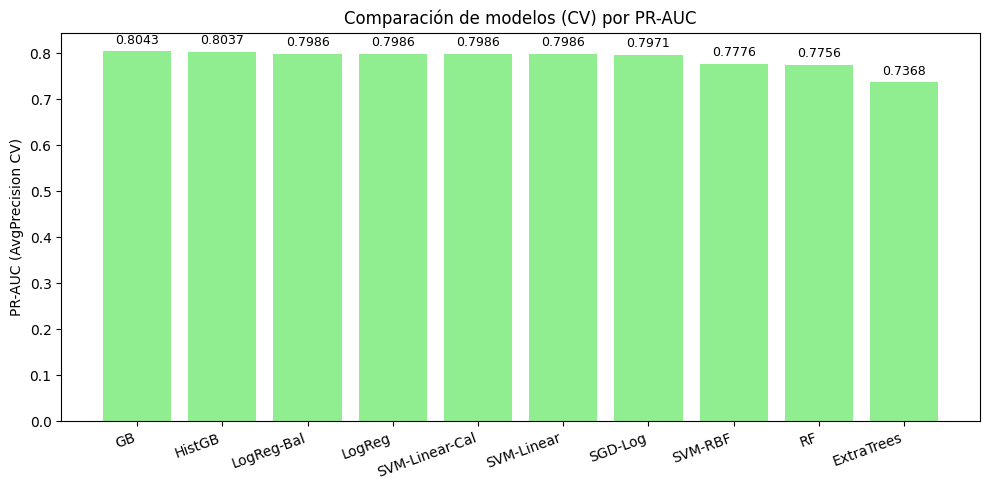

In [10]:
# === 1) Entrenamiento y evaluación por CV ===
resultados_cv = []
modelos_cv_entrenados = {}

for nombre, pipe in pipelines.items():
    # entrenamos dentro de la función de CV
    resumen, _df_folds = evaluar_modelo_cv(
        nombre, pipe, X, y,
        cv_splits=5, stratified=True, average="binary"
    )

    # guardamos modelo reentrenado en TODO el dataset (para usar después)
    pipe.fit(X, y)
    modelos_cv_entrenados[nombre] = pipe

    resultados_cv.append({
        "Modelo": nombre,
        "AvgPrecision(PR-AUC)": resumen.get("avg_precision", np.nan),
        "F1": resumen.get("f1", np.nan),
        "Precision": resumen.get("precision", np.nan),
        "Recall": resumen.get("recall", np.nan),
        "ROC-AUC": resumen.get("roc_auc", np.nan),
        "Accuracy": resumen.get("accuracy", np.nan),
    })

# === 2) Ranking de modelos (criterio: PR-AUC → F1) ===
df_rank_cv = pd.DataFrame(resultados_cv).sort_values(
    by=["AvgPrecision(PR-AUC)", "F1"],
    ascending=False
).reset_index(drop=True)

print("\n===== Ranking (cross validation) — Prioridad: PR-AUC → F1 =====")
print(df_rank_cv.round(4).to_string(index=False))

# Guardar el mejor modelo de CV
mejor_cv = df_rank_cv.iloc[0]["Modelo"]
modelo_ganador_cv = modelos_cv_entrenados[mejor_cv]

print(f"\nMejor modelo en CV (criterio PR-AUC → F1): {mejor_cv}")
print("Modelo ganador cargado en variable 'modelo_ganador_cv'.")
print("Este modelo servirá como base para fine tuning y comparativas posteriores.")

# === 3) Gráfica comparativa de PR-AUC (CV promedio) ===
orden_modelos_cv = df_rank_cv["Modelo"].tolist()
pr_auc_vals_cv   = df_rank_cv["AvgPrecision(PR-AUC)"].tolist()

plt.figure(figsize=(10, 5))
x = np.arange(len(orden_modelos_cv))
bars = plt.bar(x, pr_auc_vals_cv, color="lightgreen")

plt.xticks(x, orden_modelos_cv, rotation=20, ha="right")
plt.ylabel("PR-AUC (AvgPrecision CV)")
plt.title("Comparación de modelos (CV) por PR-AUC")

for xi, bi, val in zip(x, bars, pr_auc_vals_cv):
    plt.text(
        xi, bi.get_height() + 0.01,
        f"{val:.4f}",
        ha="center", va="bottom", fontsize=9
    )

plt.tight_layout()
plt.show()

## Fine tunning del modelo ganador

### Fine tunning con Grid Search CV

Fitting 5 folds for each of 2187 candidates, totalling 10935 fits
Mejores hiperparámetros (fine-tuning): {'learning_rate': 0.05, 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200, 'n_iter_no_change': None, 'subsample': 0.7}
Mejor PR-AUC CV (fine-tuning): 0.8058585712327041

=== Test (fine-tuning actual) ===
PR-AUC   : 0.8023707366419459
F1       : 0.7565381128391101
Precision: 0.727370256135175
Recall   : 0.7881429816913688
ROC-AUC  : 0.8213709601079954
Accuracy : 0.7422474896633195


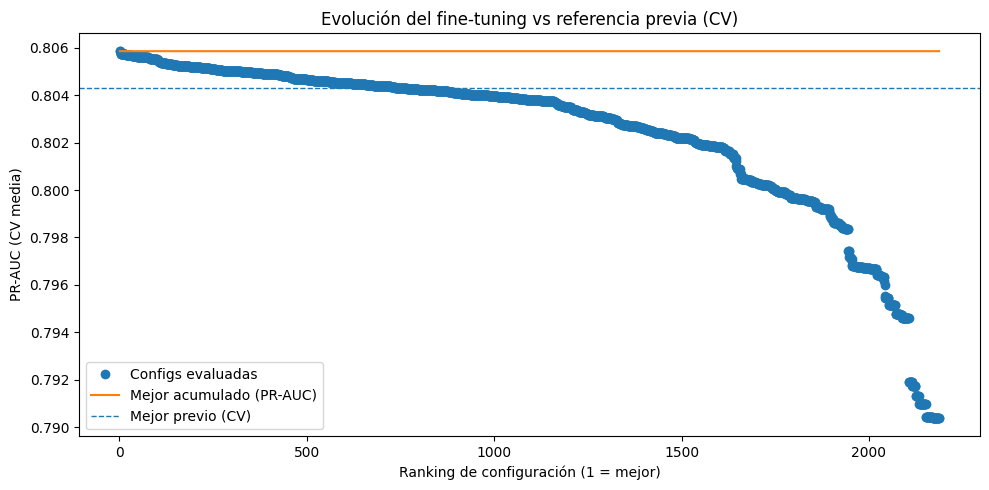

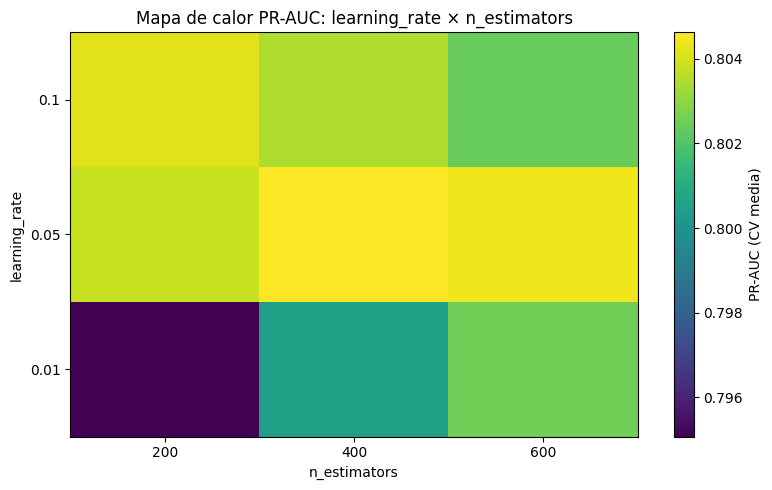

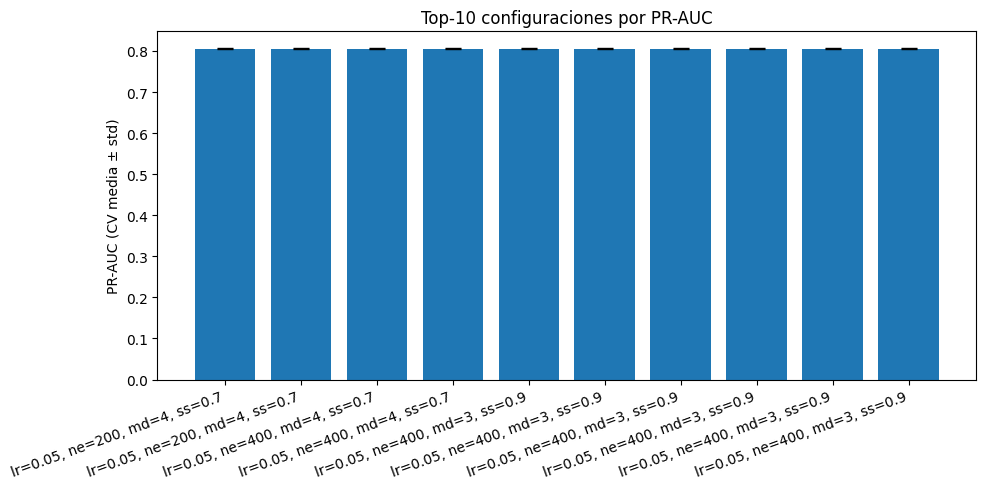

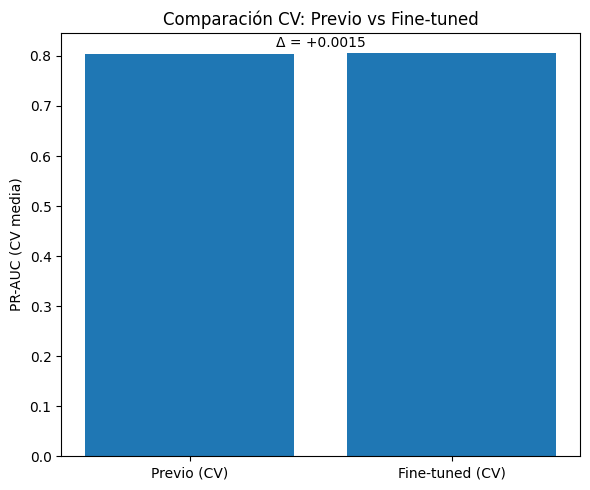

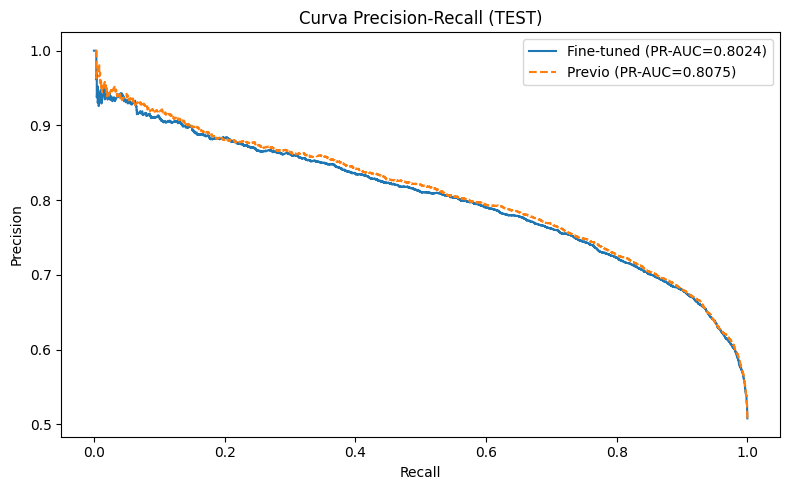

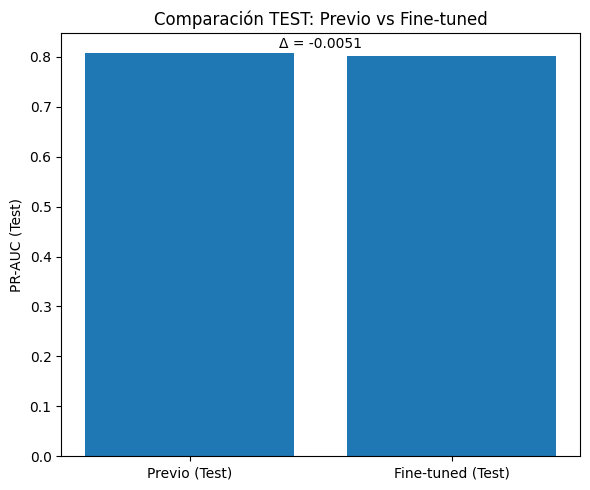

In [11]:
prev_cv_pr_auc_mean = None
prev_cv_pr_auc_std  = None
prev_test_pr_auc    = None
modelo_previo       = None

try:
    # objeto ganador previo (por CV)
    modelo_previo = modelo_ganador_cv
except NameError:
    modelo_previo = None

# media CV del ganador previo
try:
    if 'df_rank_cv' in globals():
        if 'mejor_cv' in globals():
            prev_cv_pr_auc_mean = float(
                df_rank_cv.loc[df_rank_cv["Modelo"] == mejor_cv, "AvgPrecision(PR-AUC)"].iloc[0]
            )
        else:
            # si no tenemos 'mejor_cv', tomamos la primera fila (ya ordenada)
            prev_cv_pr_auc_mean = float(df_rank_cv.iloc[0]["AvgPrecision(PR-AUC)"])
            mejor_cv = df_rank_cv.iloc[0]["Modelo"]
except Exception as e:
    print(f"[AVISO] No pude derivar prev_cv_pr_auc_mean desde df_rank_cv: {e}")

# std CV del ganador previo (si guardaste los folds)
try:
    if 'fold_scores_por_modelo' in globals() and 'mejor_cv' in globals():
        prev_cv_pr_auc_std = float(np.std(fold_scores_por_modelo[mejor_cv], ddof=1))
except Exception as e:
    pass  # es opcional

# PR-AUC en TEST del ganador previo (si tenemos el objeto)
try:
    if (modelo_previo is not None) and hasattr(modelo_previo, "predict_proba"):
        y_score_prev = modelo_previo.predict_proba(X_test)[:, 1]
        prev_test_pr_auc = float(average_precision_score(y_test, y_score_prev))
except Exception as e:
    print(f"[AVISO] No pude calcular prev_test_pr_auc desde modelo_previo: {e}")

# Mensajes informativos
if prev_cv_pr_auc_mean is None:
    print("[AVISO] No se encontró la media CV previa. La comparación CV mostrará solo el fine-tuned.")
if prev_test_pr_auc is None:
    print("[AVISO] No se encontró el PR-AUC en TEST previo. La comparación TEST mostrará solo el fine-tuned.")

# =========================
# 1) Modelo base + búsqueda (fine-tuning)
# =========================
modelo_base = GradientBoostingClassifier(random_state=42)

param_grid = {
    "n_estimators":      [200, 400, 600],
    "learning_rate":     [0.01, 0.05, 0.1],
    "max_depth":         [2, 3, 4],
    "subsample":         [0.7, 0.9, 1.0],
    "max_features":      ["sqrt", "log2", None],
    "min_samples_leaf":  [1, 5, 10],
    "min_samples_split": [2, 5, 10],
    "n_iter_no_change":  [None],
}

scorers = {"ap": "average_precision", "f1": "f1"}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=modelo_base,
    param_grid=param_grid,
    scoring=scorers,
    refit="ap",   # PR-AUC como métrica principal
    cv=cv,
    verbose=1,
    n_jobs=-1,
    error_score="raise"
)
grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros (fine-tuning):", grid_search.best_params_)
print("Mejor PR-AUC CV (fine-tuning):", grid_search.best_score_)

# =========================
# 2) Evaluación en TEST (fine-tuned actual)
# =========================
best_gb = grid_search.best_estimator_
y_pred  = best_gb.predict(X_test)
y_score = best_gb.predict_proba(X_test)[:, 1]

curr_test_pr_auc = average_precision_score(y_test, y_score)
print("\n=== Test (fine-tuning actual) ===")
print("PR-AUC   :", curr_test_pr_auc)
print("F1       :", f1_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_score))
print("Accuracy :", accuracy_score(y_test, y_pred))

# =========================
# 3) CV results para gráficas de fine-tuning
# =========================
cvres = pd.DataFrame(grid_search.cv_results_).rename(columns={
    "mean_test_ap": "mean_pr_auc",
    "std_test_ap":  "std_pr_auc",
})
cvres["rank_pr_auc"] = cvres["rank_test_ap"]

best_row = cvres.loc[cvres["rank_pr_auc"].idxmin()]
curr_cv_pr_auc_mean = float(best_row["mean_pr_auc"])
curr_cv_pr_auc_std  = float(best_row["std_pr_auc"])

# =========================
# 4) GRÁFICAS (fine-tuning + comparativas)
# =========================

# A) Evolución por ranking + mejor acumulado + referencia CV PREVIA
cvres_sorted = cvres.sort_values("rank_pr_auc")
x = np.arange(1, len(cvres_sorted) + 1)
y = cvres_sorted["mean_pr_auc"].values
y_cummax = np.maximum.accumulate(y)

plt.figure(figsize=(10, 5))
plt.plot(x, y, marker="o", linestyle="", label="Configs evaluadas")
plt.plot(x, y_cummax, linestyle="-", label="Mejor acumulado (PR-AUC)")
if prev_cv_pr_auc_mean is not None:
    plt.axhline(prev_cv_pr_auc_mean, linestyle="--", linewidth=1, label="Mejor previo (CV)")
plt.xlabel("Ranking de configuración (1 = mejor)")
plt.ylabel("PR-AUC (CV media)")
plt.title("Evolución del fine-tuning vs referencia previa (CV)")
plt.legend()
plt.tight_layout()
plt.show()

# B) Heatmap learning_rate × n_estimators (PR-AUC CV medio)
heat_df = (cvres
           .groupby(["param_learning_rate", "param_n_estimators"])["mean_pr_auc"]
           .mean()
           .unstack("param_n_estimators"))
plt.figure(figsize=(8, 5))
plt.imshow(heat_df.values, aspect="auto", origin="lower")
plt.xticks(ticks=np.arange(len(heat_df.columns)), labels=heat_df.columns, rotation=0)
plt.yticks(ticks=np.arange(len(heat_df.index)), labels=heat_df.index)
plt.colorbar(label="PR-AUC (CV media)")
plt.xlabel("n_estimators")
plt.ylabel("learning_rate")
plt.title("Mapa de calor PR-AUC: learning_rate × n_estimators")
plt.tight_layout()
plt.show()

# C) Top-k configuraciones por PR-AUC (CV ± std)
k = 10
topk = cvres.nsmallest(k, "rank_pr_auc")
plt.figure(figsize=(10, 5))
idx = np.arange(len(topk))
plt.bar(idx, topk["mean_pr_auc"].values, yerr=topk["std_pr_auc"].values, capsize=6)
labels = [
    f"lr={lr}, ne={ne}, md={md}, ss={ss}"
    for lr, ne, md, ss in zip(topk["param_learning_rate"],
                              topk["param_n_estimators"],
                              topk["param_max_depth"],
                              topk["param_subsample"])
]
plt.xticks(idx, labels, rotation=20, ha="right")
plt.ylabel("PR-AUC (CV media ± std)")
plt.title(f"Top-{k} configuraciones por PR-AUC")
plt.tight_layout()
plt.show()

# D) Barras PREVIO vs ACTUAL (CV)
if prev_cv_pr_auc_mean is not None:
    labels_cv = ["Previo (CV)", "Fine-tuned (CV)"]
    vals_cv   = [prev_cv_pr_auc_mean, curr_cv_pr_auc_mean]
    errs_cv   = [prev_cv_pr_auc_std, curr_cv_pr_auc_std] if prev_cv_pr_auc_std is not None else None

    plt.figure(figsize=(6, 5))
    plt.bar(np.arange(2), vals_cv, yerr=errs_cv, capsize=6)
    plt.xticks(np.arange(2), labels_cv)
    plt.ylabel("PR-AUC (CV media)")
    plt.title("Comparación CV: Previo vs Fine-tuned")
    delta_cv = curr_cv_pr_auc_mean - prev_cv_pr_auc_mean
    plt.text(0.5, max(vals_cv) + 0.005, f"Δ = {delta_cv:+.4f}", ha="center", va="bottom")
    plt.tight_layout()
    plt.show()

# E) Curva Precision-Recall en TEST (Previo vs Fine-tuned) + Barras PR-AUC(TEST)
prec_curr, rec_curr, _ = precision_recall_curve(y_test, y_score)

plt.figure(figsize=(8, 5))
plt.plot(rec_curr, prec_curr, label=f"Fine-tuned (PR-AUC={curr_test_pr_auc:.4f})")
if (modelo_previo is not None) and (prev_test_pr_auc is not None):
    prec_prev, rec_prev, _ = precision_recall_curve(y_test, y_score_prev)
    plt.plot(rec_prev, prec_prev, linestyle="--", label=f"Previo (PR-AUC={prev_test_pr_auc:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall (TEST)")
plt.legend()
plt.tight_layout()
plt.show()

labels_t, vals_t = ["Fine-tuned (Test)"], [curr_test_pr_auc]
if prev_test_pr_auc is not None:
    labels_t.insert(0, "Previo (Test)")
    vals_t.insert(0, prev_test_pr_auc)

plt.figure(figsize=(6, 5))
plt.bar(np.arange(len(vals_t)), vals_t)
plt.xticks(np.arange(len(vals_t)), labels_t)
plt.ylabel("PR-AUC (Test)")
plt.title("Comparación TEST: Previo vs Fine-tuned")
if len(vals_t) == 2:
    delta_t = vals_t[1] - vals_t[0]
    plt.text(0.5, max(vals_t) + 0.005, f"Δ = {delta_t:+.4f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

### Busqueda de mejores hiperparametros alrededor de los parametros del fine tunning

In [12]:
best_params_base = grid_search.best_params_ # Parametros encontrados del fine tunning anterior

# Definir un grid “fino” alrededor de esos valores
def around(val, factors=(0.5, 1.0, 1.5), clip_min=None, clip_max=None):
    arr = sorted(set([val*f for f in factors]))
    if clip_min is not None: arr = [max(clip_min, x) for x in arr]
    if clip_max is not None: arr = [min(clip_max, x) for x in arr]
    return arr

grid = {
    "learning_rate": around(best_params_base["learning_rate"], (0.5, 1.0, 1.5), 1e-3, 0.5),
    "max_depth":     sorted(set([max(2, best_params_base["max_depth"]-1),
                                 best_params_base["max_depth"],
                                 best_params_base["max_depth"]+1])),
    "subsample":     [max(0.6, best_params_base["subsample"]-0.1),
                      best_params_base["subsample"],
                      min(1.0, best_params_base["subsample"]+0.1)],
    "max_features":  [best_params_base["max_features"]],  # o prueba ["sqrt", "log2", None]
    "min_samples_leaf": [max(1, best_params_base["min_samples_leaf"]//2),
                         best_params_base["min_samples_leaf"],
                         best_params_base["min_samples_leaf"]*2],
    "min_samples_split": [max(2, best_params_base["min_samples_split"]//2),
                          best_params_base["min_samples_split"],
                          min(100, best_params_base["min_samples_split"]*2)],
    # Mantén early stopping si te funcionó bien:
    "n_iter_no_change": [best_params_base.get("n_iter_no_change", None)],
    "validation_fraction": [best_params_base.get("validation_fraction", 0.1)],
    # Incluye n_estimators si NO estás usando Halving como recurso:
    "n_estimators": [max(100, int(best_params_base.get("n_estimators", 600)*f)) for f in (0.75, 1.0, 1.25)],
}

# Instanciar modelo base con los mejores parámetros previos
gb_base = GradientBoostingClassifier(random_state=42, **best_params_base)

# GridSearchCV: refit por PR-AUC (Average Precision)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gridcv = GridSearchCV(
    estimator=gb_base,
    param_grid=grid,
    scoring={"ap": "average_precision", "f1": "f1"},
    refit="ap",               # selecciona por PR-AUC (tu criterio principal)
    cv=cv,
    n_jobs=-1,
    verbose=1,
)
gridcv.fit(X_train, y_train)

print("Mejor combinación (CV, PR-AUC):", gridcv.best_params_)
print("Mejor PR-AUC CV:", gridcv.best_score_)

# === 5) Evaluación en test del mejor modelo ===
best_gb = gridcv.best_estimator_
y_pred  = best_gb.predict(X_test)
y_score = best_gb.predict_proba(X_test)[:, 1]

print("\n=== Métricas en TEST ===")
print("PR-AUC   :", average_precision_score(y_test, y_score))
print("F1       :", f1_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_score))
print("Accuracy :", accuracy_score(y_test, y_pred))

Fitting 5 folds for each of 729 candidates, totalling 3645 fits
Mejor combinación (CV, PR-AUC): {'learning_rate': 0.05, 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 250, 'n_iter_no_change': None, 'subsample': 0.7, 'validation_fraction': 0.1}
Mejor PR-AUC CV: 0.8060630880789919

=== Métricas en TEST ===
PR-AUC   : 0.8022700724733298
F1       : 0.7561758548499651
Precision: 0.7274436090225563
Recall   : 0.7872711421098518
ROC-AUC  : 0.8214502658399677
Accuracy : 0.7420259893679858


In [13]:

# --- 1) Recuperar modelos y métricas de ambos tunings ---
# Grid 1 (fine-tuning inicial)
gb1 = grid_search.best_estimator_
cv1_mean = float(grid_search.best_score_)
# std de CV1 (si lo quieres para barras de error):
cvres1 = pd.DataFrame(grid_search.cv_results_).rename(columns={"mean_test_ap":"mean_pr_auc","std_test_ap":"std_pr_auc"})
cv1_std  = float(cvres1.loc[cvres1["rank_test_ap"].idxmin(),"std_pr_auc"])
# TEST
y_score1 = gb1.predict_proba(X_test)[:, 1]
test1_ap = float(average_precision_score(y_test, y_score1))

# Grid 2 (búsqueda fina)
gb2 = gridcv.best_estimator_
cv2_mean = float(gridcv.best_score_)
cvres2 = pd.DataFrame(gridcv.cv_results_).rename(columns={"mean_test_ap":"mean_pr_auc","std_test_ap":"std_pr_auc"})
cv2_std  = float(cvres2.loc[cvres2["rank_test_ap"].idxmin(),"std_pr_auc"])
y_score2 = gb2.predict_proba(X_test)[:, 1]
test2_ap = float(average_precision_score(y_test, y_score2))

# --- 2) Tabla de comparación (útil para logs/gráficas) ---
cmp = pd.DataFrame([
    {"Modelo":"GB Grid 1", "PR-AUC CV":cv1_mean, "PR-AUC CV std":cv1_std, "PR-AUC TEST":test1_ap},
    {"Modelo":"GB Grid 2", "PR-AUC CV":cv2_mean, "PR-AUC CV std":cv2_std, "PR-AUC TEST":test2_ap},
]).sort_values(by=["PR-AUC CV","PR-AUC TEST"], ascending=False).reset_index(drop=True)

print("\n=== Comparativa GB (Grid 1 vs Grid 2) ===")
print(cmp.round(4).to_string(index=False))

# --- 3) Regla de selección: CV principal, TEST como desempate ---
eps = 1e-6  # tolerancia para empates numéricos
if (cv2_mean - cv1_mean) > eps:
    gb_best = gb2
    gb_best_label = "GB tuneado (Grid 2)"
elif (cv1_mean - cv2_mean) > eps:
    gb_best = gb1
    gb_best_label = "GB tuneado (Grid 1)"
else:
    # Empate en CV: desempatar por TEST
    if test2_ap > test1_ap + eps:
        gb_best = gb2
        gb_best_label = "GB tuneado (Grid 2)"
    else:
        gb_best = gb1
        gb_best_label = "GB tuneado (Grid 1)"

print(f"\nSeleccionado como 'gb_best': {gb_best_label}")

# --- 4) (Opcional) Diccionario por si quieres usar después en gráficas ---
gb_tuning_summary = {
    "grid1": {"model": gb1, "cv_mean": cv1_mean, "cv_std": cv1_std, "test_ap": test1_ap, "y_score": y_score1},
    "grid2": {"model": gb2, "cv_mean": cv2_mean, "cv_std": cv2_std, "test_ap": test2_ap, "y_score": y_score2},
    "best":  {"model": gb_best, "label": gb_best_label}
}



=== Comparativa GB (Grid 1 vs Grid 2) ===
   Modelo  PR-AUC CV  PR-AUC CV std  PR-AUC TEST
GB Grid 2     0.8061         0.0011       0.8023
GB Grid 1     0.8059         0.0016       0.8024

Seleccionado como 'gb_best': GB tuneado (Grid 2)


### Comparativas de los resultados

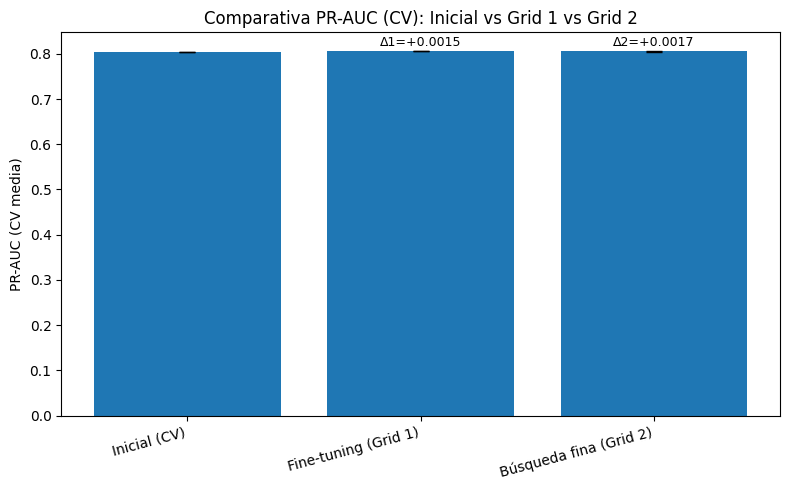

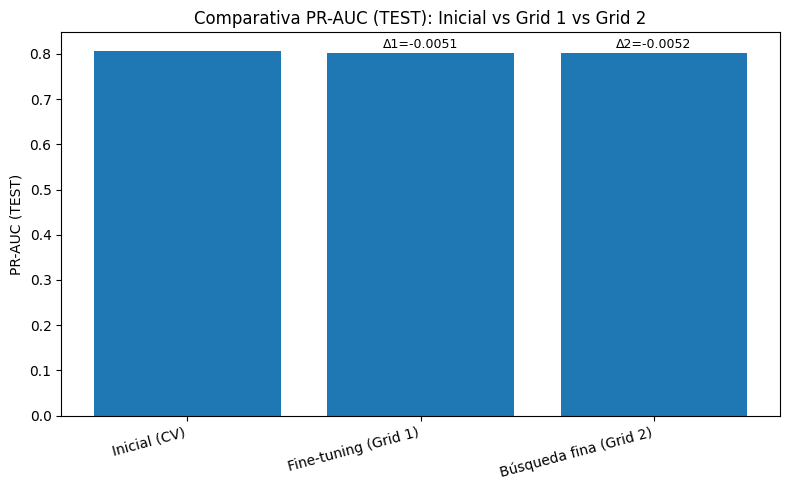

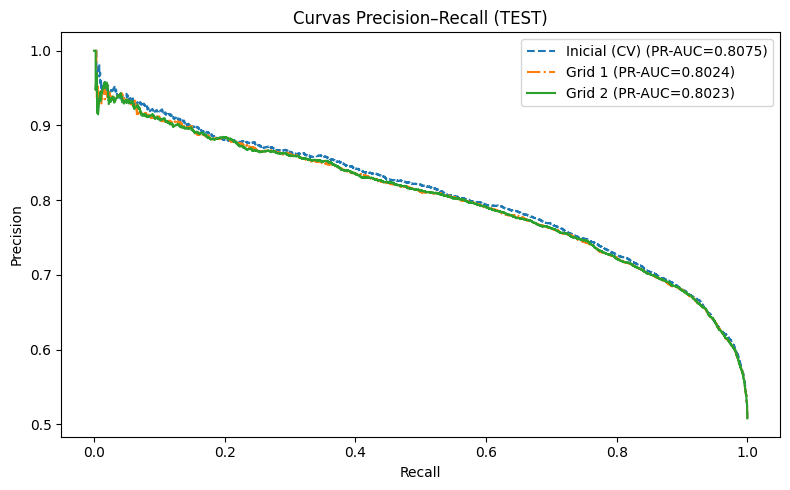

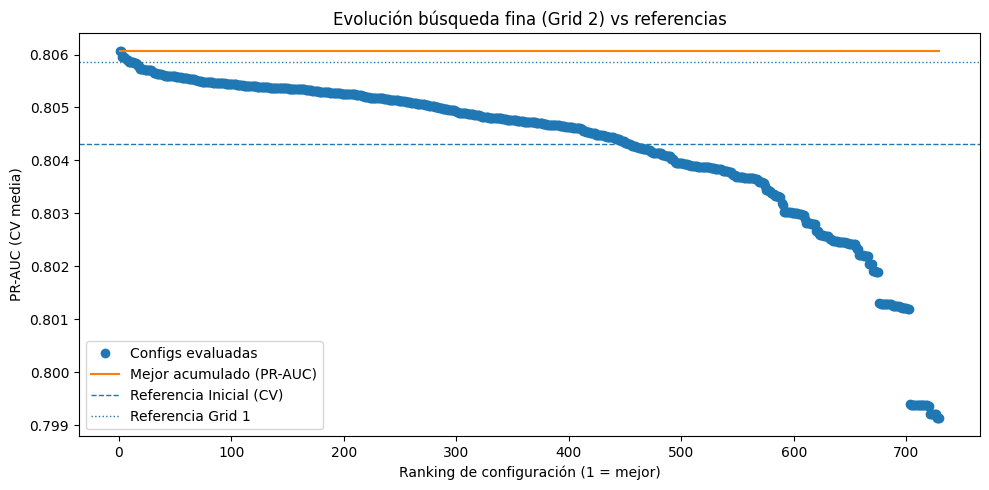

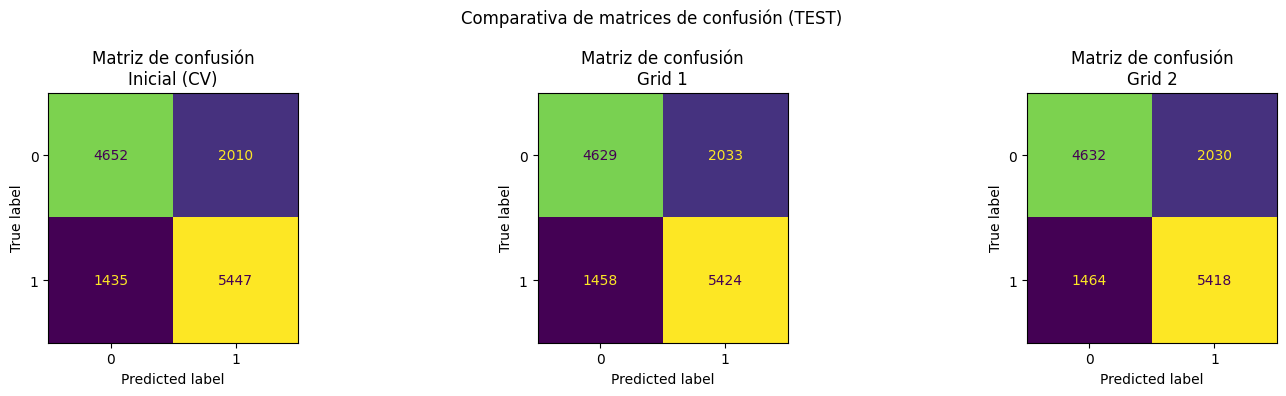

In [14]:

# =========================
# HELPERS
# =========================
def _safe_pr_auc_test(model, X_test, y_test):
    """Devuelve (pr_auc, (prec, rec, thr)) si hay predict_proba; en otro caso (None, (None, None, None))."""
    if model is None or not hasattr(model, "predict_proba"):
        return None, (None, None, None)
    y_score = model.predict_proba(X_test)[:, 1]
    pr_auc = float(average_precision_score(y_test, y_score))
    prec, rec, thr = precision_recall_curve(y_test, y_score)
    return pr_auc, (prec, rec, thr)

def _std_from_folds(model_name, folds_dict):
    """Devuelve std muestral de PR-AUC entre folds si existe en folds_dict[model_name]."""
    if folds_dict is None or model_name not in folds_dict:
        return None
    vals = np.asarray(folds_dict[model_name], dtype=float)
    return float(np.std(vals, ddof=1)) if len(vals) > 1 else None

# =========================
# 1) BASELINE (fase inicial: preferimos CV; si no, Split)
# =========================
modelo_previo = None
prev_cv_mean = None
prev_cv_std  = None
prev_label   = None

try:
    # Preferimos el ganador por CV si existe
    modelo_previo = modelo_ganador_cv
    prev_label    = "Inicial (CV)"
    if 'df_rank_cv' in globals() and 'mejor_cv' in globals():
        prev_cv_mean = float(df_rank_cv.loc[df_rank_cv["Modelo"] == mejor_cv, "AvgPrecision(PR-AUC)"].iloc[0])
    elif 'df_rank_cv' in globals():
        prev_cv_mean = float(df_rank_cv.iloc[0]["AvgPrecision(PR-AUC)"])
        mejor_cv = df_rank_cv.iloc[0]["Modelo"]
    # std desde folds (opcional, si guardaste fold_scores_por_modelo)
    prev_cv_std = _std_from_folds(mejor_cv, globals().get('fold_scores_por_modelo', None))
except Exception:
    pass

if modelo_previo is None:
    # Caer a Split si no hay CV
    try:
        modelo_previo = modelo_ganador_split
        prev_label    = "Inicial (Split)"
        if 'df_rank_split' in globals():
            prev_cv_mean = float(df_rank_split.iloc[0]["AvgPrecision(PR-AUC)"])
            prev_cv_std  = None  # en split no hay folds
    except Exception:
        pass

# PR-AUC en TEST y curvas PR del baseline
prev_test_pr_auc, (prec_prev, rec_prev, _) = _safe_pr_auc_test(modelo_previo, X_test, y_test)

# =========================
# 2) FINE-TUNING INICIAL (Grid 1): métricas CV y TEST
# =========================
ft1_cv_mean = float(grid_search.best_score_) if 'grid_search' in globals() else None
ft1_model   = grid_search.best_estimator_   if 'grid_search' in globals() else None
ft1_test_pr_auc, (prec_ft1, rec_ft1, _) = _safe_pr_auc_test(ft1_model, X_test, y_test)

# =========================
# 3) BÚSQUEDA FINA (Grid 2): métricas CV y TEST
# =========================
cvres_fine = pd.DataFrame(gridcv.cv_results_).rename(columns={
    "mean_test_ap":"mean_pr_auc", "std_test_ap":"std_pr_auc"
})
cvres_fine["rank_pr_auc"] = cvres_fine["rank_test_ap"]

best_row_fine = cvres_fine.loc[cvres_fine["rank_pr_auc"].idxmin()]
ft2_cv_mean = float(best_row_fine["mean_pr_auc"])
ft2_cv_std  = float(best_row_fine["std_pr_auc"]) if pd.notnull(best_row_fine["std_pr_auc"]) else None

ft2_model        = gridcv.best_estimator_
ft2_test_pr_auc, (prec_ft2, rec_ft2, _) = _safe_pr_auc_test(ft2_model, X_test, y_test)

# =========================
# 4) GRÁFICAS COMPARATIVAS (CV y TEST)
# =========================

# ---- A) Barras PR-AUC (CV): Inicial vs Grid 1 vs Grid 2 ----
labels_cv = []
vals_cv   = []
errs_cv   = []

if prev_cv_mean is not None:
    labels_cv.append(prev_label)
    vals_cv.append(prev_cv_mean)
    errs_cv.append(prev_cv_std)

if ft1_cv_mean is not None:
    labels_cv.append("Fine-tuning (Grid 1)")
    vals_cv.append(ft1_cv_mean)
    errs_cv.append(None)

labels_cv.append("Búsqueda fina (Grid 2)")
vals_cv.append(ft2_cv_mean)
errs_cv.append(ft2_cv_std)

plt.figure(figsize=(8, 5))
x = np.arange(len(vals_cv))
plt.bar(x, vals_cv, yerr=[(e if e is not None else 0) for e in errs_cv], capsize=6)
plt.xticks(x, labels_cv, rotation=15, ha="right")
plt.ylabel("PR-AUC (CV media)")
plt.title("Comparativa PR-AUC (CV): Inicial vs Grid 1 vs Grid 2")

# Δ totales vs primera barra
base_cv = vals_cv[0]
for xi, val in enumerate(vals_cv[1:], start=1):
    plt.text(xi, val + 0.005, f"Δ{xi}={val - base_cv:+.4f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# ---- B) Barras PR-AUC (TEST): Inicial vs Grid 1 vs Grid 2 ----
labels_t = []
vals_t   = []

if prev_test_pr_auc is not None:
    labels_t.append(prev_label)
    vals_t.append(prev_test_pr_auc)

if ft1_test_pr_auc is not None:
    labels_t.append("Fine-tuning (Grid 1)")
    vals_t.append(ft1_test_pr_auc)

labels_t.append("Búsqueda fina (Grid 2)")
vals_t.append(ft2_test_pr_auc)

plt.figure(figsize=(8, 5))
x = np.arange(len(vals_t))
plt.bar(x, vals_t)
plt.xticks(x, labels_t, rotation=15, ha="right")
plt.ylabel("PR-AUC (TEST)")
plt.title("Comparativa PR-AUC (TEST): Inicial vs Grid 1 vs Grid 2")

if len(vals_t) >= 2:
    base_t = vals_t[0]
    for xi, val in enumerate(vals_t[1:], start=1):
        plt.text(xi, val + 0.005, f"Δ{xi}={val - base_t:+.4f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# ---- C) Curvas Precision–Recall (TEST) superpuestas ----
plt.figure(figsize=(8, 5))
if prev_test_pr_auc is not None and prec_prev is not None:
    plt.plot(rec_prev,  prec_prev,  linestyle="--", label=f"{prev_label} (PR-AUC={prev_test_pr_auc:.4f})")
if ft1_test_pr_auc is not None and prec_ft1 is not None:
    plt.plot(rec_ft1,   prec_ft1,   linestyle="-.", label=f"Grid 1 (PR-AUC={ft1_test_pr_auc:.4f})")
plt.plot(rec_ft2,   prec_ft2,   linestyle="-",  label=f"Grid 2 (PR-AUC={ft2_test_pr_auc:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curvas Precision–Recall (TEST)")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 5) DIAGNÓSTICO DEL GRID 2 (evolución) + MATRICES DE CONFUSIÓN
# =========================

# ---- D) Evolución (ranking) con best-so-far ----
cvres_sorted = cvres_fine.sort_values("rank_pr_auc")
x = np.arange(1, len(cvres_sorted) + 1)
y = cvres_sorted["mean_pr_auc"].values
y_cummax = np.maximum.accumulate(y)

plt.figure(figsize=(10, 5))
plt.plot(x, y, marker="o", linestyle="", label="Configs evaluadas")
plt.plot(x, y_cummax, linestyle="-", label="Mejor acumulado (PR-AUC)")
if prev_cv_mean is not None:
    plt.axhline(prev_cv_mean, linestyle="--", linewidth=1, label=f"Referencia {prev_label}")
if ft1_cv_mean is not None:
    plt.axhline(ft1_cv_mean, linestyle=":",  linewidth=1, label="Referencia Grid 1")
plt.xlabel("Ranking de configuración (1 = mejor)")
plt.ylabel("PR-AUC (CV media)")
plt.title("Evolución búsqueda fina (Grid 2) vs referencias")
plt.legend()
plt.tight_layout()
plt.show()

# ---- E) Matrices de confusión (TEST) para Baseline, Grid 1 y Grid 2 ----
modelos_conf = {
    prev_label if prev_label is not None else "Inicial": modelo_previo,
    "Grid 1": ft1_model,
    "Grid 2": ft2_model
}

# Filtrar los None por si faltara algún modelo
modelos_conf = {k: v for k, v in modelos_conf.items() if v is not None}

ncols = len(modelos_conf)
if ncols > 0:
    fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 4))
    if ncols == 1:
        axes = [axes]  # homogenizar iteración

    for ax, (label, model) in zip(axes, modelos_conf.items()):
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(ax=ax, values_format="d", colorbar=False)
        ax.set_title(f"Matriz de confusión\n{label}")

    plt.suptitle("Comparativa de matrices de confusión (TEST)")
    plt.tight_layout()
    plt.show()
else:
    print("[AVISO] No hay modelos disponibles para matrices de confusión.")


### Soft Voting (promedio de probabilidades)


=== VotingSoft (VotingClassifier) ===
Accuracy: 0.7369 | Precision: 0.7217 | Recall: 0.7851 | F1: 0.7520 | ROC-AUC: 0.8154 | PR-AUC: 0.7965
              precision    recall  f1-score   support

           0     0.7558    0.6872    0.7199      6662
           1     0.7217    0.7851    0.7520      6882

    accuracy                         0.7369     13544
   macro avg     0.7387    0.7361    0.7360     13544
weighted avg     0.7385    0.7369    0.7362     13544


===== VotingSoft | Fold 1/5 (VotingClassifier) =====
              precision    recall  f1-score   support

           0     0.7615    0.7010    0.7300      6662
           1     0.7312    0.7874    0.7583      6882

    accuracy                         0.7449     13544
   macro avg     0.7463    0.7442    0.7441     13544
weighted avg     0.7461    0.7449    0.7444     13544


===== VotingSoft | Fold 2/5 (VotingClassifier) =====
              precision    recall  f1-score   support

           0     0.7588    0.6912    0.723

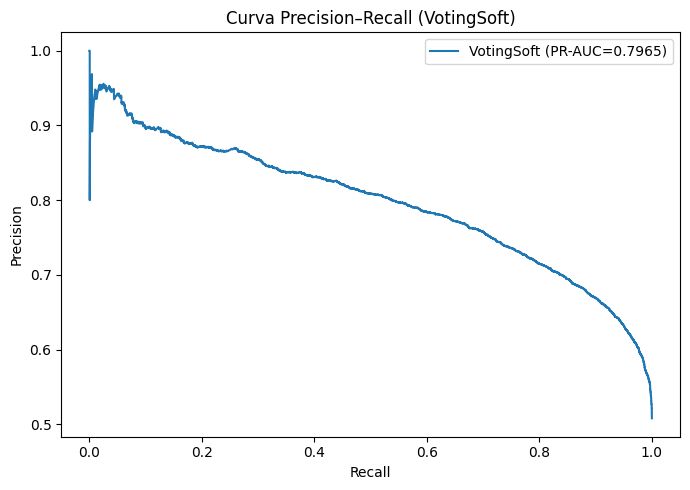

In [17]:
# === 0) Reconstrucción segura de X_all / y_all ===
# Garantizar que son pandas DataFrame/Series para evaluacion CV
X_all = pd.concat([pd.DataFrame(X_train), pd.DataFrame(X_test)], axis=0, ignore_index=True)
y_all = pd.concat([
    pd.Series(y_train).reset_index(drop=True),
    pd.Series(y_test).reset_index(drop=True)
], axis=0).reset_index(drop=True)

assert len(X_all) == len(y_all), f"Longitudes distintas: X_all={len(X_all)} vs y_all={len(y_all)}"
assert len(X_train) == len(y_train)
assert len(X_test)  == len(y_test)

# === 1) Define modelos base ===
gb_best_current = gb_best  # mejor GB obtenido de tu comparativa (Grid1 vs Grid2)

rf  = RandomForestClassifier(n_estimators=400, random_state=42)
et  = ExtraTreesClassifier(n_estimators=600, random_state=42)
hgb = HistGradientBoostingClassifier(random_state=42)
lr  = LogisticRegression(max_iter=500, class_weight="balanced")

voting_soft = VotingClassifier(
    estimators=[("gb", gb_best_current), ("rf", rf), ("et", et), ("hgb", hgb), ("lr", lr)],
    voting="soft"
)

# === 2) Evaluación en split (fit en train, eval en test) ===
res_split_vs = evaluar_modelo_split(
    "VotingSoft",
    clone(voting_soft),
    X_train, y_train, X_test, y_test,
    average="binary"
)

# === 3) Evaluación en CV (usa X_all/y_all y clona el modelo) ===
resumen_vs, _ = evaluar_modelo_cv(
    "VotingSoft",
    clone(voting_soft),
    X_all, y_all,
    cv_splits=5, stratified=True, average="binary"
)

# === 4) Curva Precision–Recall en TEST ===
voting_soft_fitted = clone(voting_soft).fit(X_train, y_train)
y_score_vs = voting_soft_fitted.predict_proba(X_test)[:, 1]
prec_vs, rec_vs, _ = precision_recall_curve(y_test, y_score_vs)
pr_auc_vs = average_precision_score(y_test, y_score_vs)

plt.figure(figsize=(7,5))
plt.plot(rec_vs, prec_vs, label=f"VotingSoft (PR-AUC={pr_auc_vs:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision–Recall (VotingSoft)")
plt.legend()
plt.tight_layout()
plt.show()

### Stacking


=== Stacking (StackingClassifier) ===
Accuracy: 0.7436 | Precision: 0.7326 | Recall: 0.7800 | F1: 0.7556 | ROC-AUC: 0.8220 | PR-AUC: 0.8024
              precision    recall  f1-score   support

           0     0.7565    0.7059    0.7303      6662
           1     0.7326    0.7800    0.7556      6882

    accuracy                         0.7436     13544
   macro avg     0.7446    0.7430    0.7430     13544
weighted avg     0.7444    0.7436    0.7432     13544


===== Stacking | Fold 1/5 (StackingClassifier) =====
              precision    recall  f1-score   support

           0     0.7640    0.7052    0.7334      6662
           1     0.7344    0.7892    0.7608      6882

    accuracy                         0.7479     13544
   macro avg     0.7492    0.7472    0.7471     13544
weighted avg     0.7490    0.7479    0.7473     13544


===== Stacking | Fold 2/5 (StackingClassifier) =====
              precision    recall  f1-score   support

           0     0.7584    0.7010    0.728

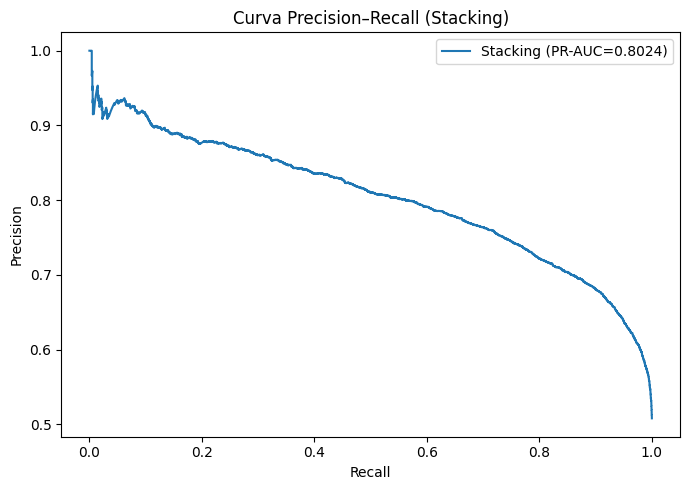

In [18]:
# === 0) Reconstrucción segura de X_all / y_all como pandas ===
X_all = pd.concat([pd.DataFrame(X_train), pd.DataFrame(X_test)], axis=0, ignore_index=True)
y_all = pd.concat([
    pd.Series(y_train).reset_index(drop=True),
    pd.Series(y_test).reset_index(drop=True)
], axis=0).reset_index(drop=True)

assert len(X_all) == len(y_all), f"Longitudes distintas: X_all={len(X_all)} vs y_all={len(y_all)}"
assert len(X_train) == len(y_train)
assert len(X_test)  == len(y_test)

# === 1) Definición del Stacking ===
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# SVC calibrado para tener predict_proba
lin_svc_cal = CalibratedClassifierCV(LinearSVC(max_iter=5000, random_state=42), cv=5)

estimators = [
    ("gb",  gb_best),  # usa el GB seleccionado (mejor entre Grid1 y Grid2)
    ("rf",  RandomForestClassifier(n_estimators=400, random_state=42)),
    ("et",  ExtraTreesClassifier(n_estimators=600, random_state=42)),
    ("hgb", HistGradientBoostingClassifier(random_state=42)),
    ("lr",  LogisticRegression(max_iter=500, class_weight="balanced")),
    ("lsvc", lin_svc_cal),
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, class_weight="balanced"),
    cv=cv,
    passthrough=True,
    n_jobs=-1
)

# === 2) Evaluación en split (fit en train, eval en test) ===
res_split_stack = evaluar_modelo_split(
    "Stacking",
    clone(stack),                # <- clonado para evitar estado residual
    X_train, y_train, X_test, y_test,
    average="binary"
)

# === 3) Evaluación en CV (usa X_all/y_all y clona el modelo) ===
resumen_stack, _ = evaluar_modelo_cv(
    "Stacking",
    clone(stack),                # <- clonado para CV
    X_all, y_all,
    cv_splits=5, stratified=True, average="binary"
)

# === 4) Curva Precision–Recall en TEST (entrena limpio y grafica) ===
stack_fitted = clone(stack).fit(X_train, y_train)
y_score_stack = stack_fitted.predict_proba(X_test)[:, 1]
prec_st, rec_st, _ = precision_recall_curve(y_test, y_score_stack)
pr_auc_st = average_precision_score(y_test, y_score_stack)

plt.figure(figsize=(7,5))
plt.plot(rec_st, prec_st, label=f"Stacking (PR-AUC={pr_auc_st:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision–Recall (Stacking)")
plt.legend()
plt.tight_layout()
plt.show()

### Comparativa final

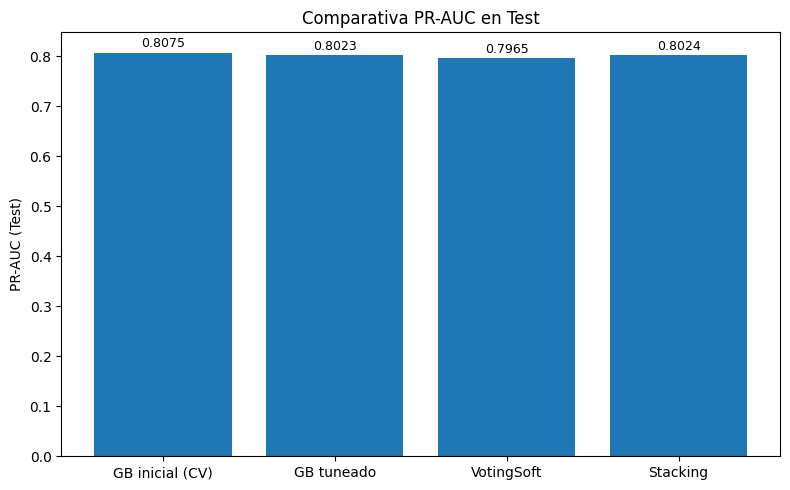

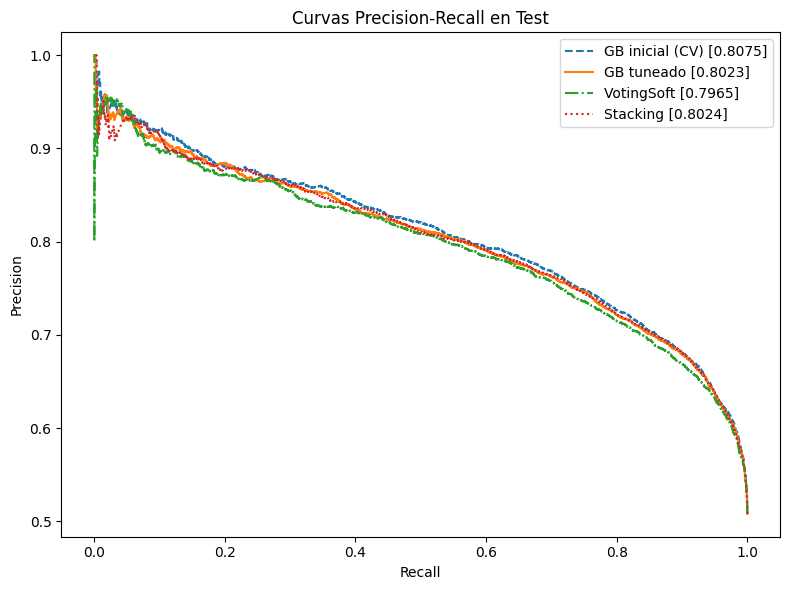

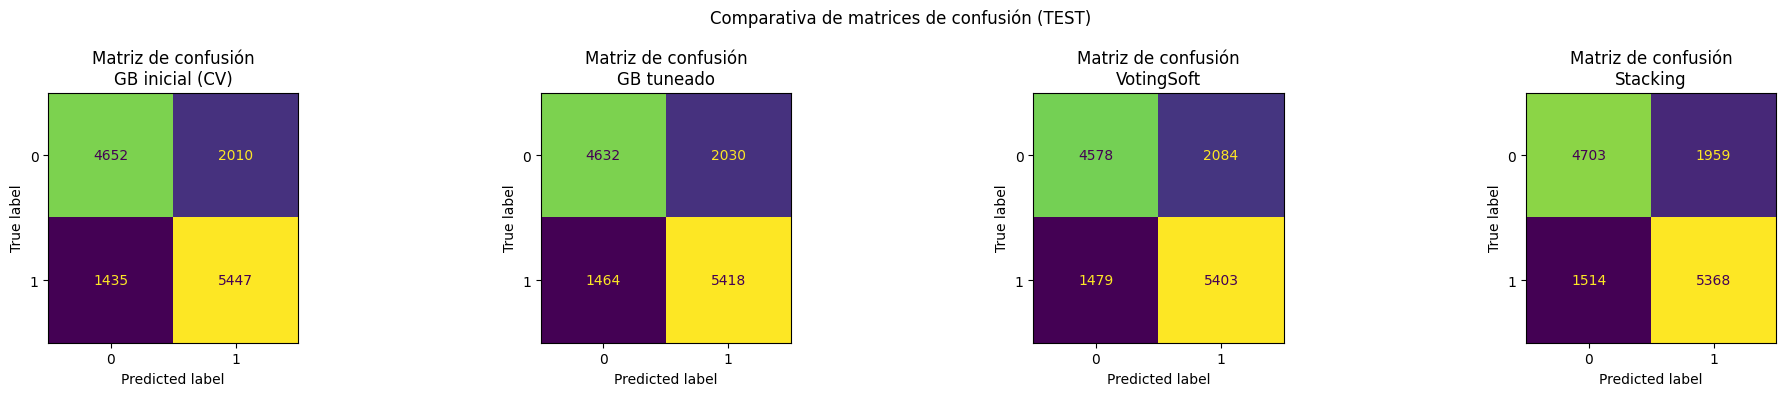

In [20]:
# === 1) GB inicial (CV) ===
y_score_gb_init = modelo_ganador_cv.predict_proba(X_test)[:, 1]
pr_auc_gb_init  = average_precision_score(y_test, y_score_gb_init)
prec_gb_init, rec_gb_init, _ = precision_recall_curve(y_test, y_score_gb_init)

# === 2) GB tuneado (fine tuning) ===
y_score_gb_best = best_gb.predict_proba(X_test)[:, 1]
pr_auc_gb_best  = average_precision_score(y_test, y_score_gb_best)
prec_gb_best, rec_gb_best, _ = precision_recall_curve(y_test, y_score_gb_best)

# === 3) VotingSoft (fit limpio y reutilizable) ===
voting_soft_fitted = voting_soft.fit(X_train, y_train)
y_score_vs = voting_soft_fitted.predict_proba(X_test)[:, 1]
pr_auc_vs  = average_precision_score(y_test, y_score_vs)
prec_vs, rec_vs, _ = precision_recall_curve(y_test, y_score_vs)

# === 4) Stacking (fit limpio y reutilizable) ===
stack_fitted = stack.fit(X_train, y_train)
y_score_st = stack_fitted.predict_proba(X_test)[:, 1]
pr_auc_st  = average_precision_score(y_test, y_score_st)
prec_st, rec_st, _ = precision_recall_curve(y_test, y_score_st)

# ==================================================
# Barras comparativas PR-AUC (TEST)
# ==================================================
labels = ["GB inicial (CV)", "GB tuneado", "VotingSoft", "Stacking"]
vals   = [pr_auc_gb_init, pr_auc_gb_best, pr_auc_vs, pr_auc_st]

plt.figure(figsize=(8, 5))
plt.bar(labels, vals)
for i, v in enumerate(vals):
    plt.text(i, v + 0.005, f"{v:.4f}", ha="center", va="bottom", fontsize=9)
plt.ylabel("PR-AUC (Test)")
plt.title("Comparativa PR-AUC en Test")
plt.tight_layout()
plt.show()

# ==================================================
# Curvas PR superpuestas (TEST)
# ==================================================
plt.figure(figsize=(8, 6))
plt.plot(rec_gb_init,  prec_gb_init,  linestyle="--", label=f"GB inicial (CV) [{pr_auc_gb_init:.4f}]")
plt.plot(rec_gb_best,  prec_gb_best,  linestyle="-",  label=f"GB tuneado [{pr_auc_gb_best:.4f}]")
plt.plot(rec_vs,       prec_vs,       linestyle="-.", label=f"VotingSoft [{pr_auc_vs:.4f}]")
plt.plot(rec_st,       prec_st,       linestyle=":",  label=f"Stacking [{pr_auc_st:.4f}]")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curvas Precision-Recall en Test")
plt.legend()
plt.tight_layout()
plt.show()

# ==================================================
# Matrices de confusión (TEST) para cada modelo
# ==================================================
modelos_conf = [
    ("GB inicial (CV)", modelo_ganador_cv),
    ("GB tuneado",      best_gb),
    ("VotingSoft",      voting_soft_fitted),
    ("Stacking",        stack_fitted),
]

fig, axes = plt.subplots(1, len(modelos_conf), figsize=(5*len(modelos_conf), 4))
if len(modelos_conf) == 1:
    axes = [axes]  # homogenizar iteración si solo hay uno

for ax, (titulo, modelo) in zip(axes, modelos_conf):
    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(f"Matriz de confusión\n{titulo}")

plt.suptitle("Comparativa de matrices de confusión (TEST)")
plt.tight_layout()
plt.show()

### Preparar y cargar el modelo ganador en un fichero para la aplicación

In [21]:
df_crudo = pd.read_pickle('./data/df_eda.pkl')

target = 'Diabetes_binary'

X_crudo = df_crudo.drop(columns=[target])
# X_crudo = df_crudo[vars_seleccionadas].copy()
y = df_crudo[target].astype(int)

In [22]:
# Cargar el modelo entrenado en un fichero pkl

cols_binarias   = ['HighBP','HighChol','Smoker','Stroke','HeartDiseaseorAttack','HvyAlcoholConsump','PhysActivity','Fruits','Veggies','NoDocbcCost','DiffWalk','Sex']
cols_continuas  = ['BMI','MentHlth','PhysHlth']
cols_ordinales  = ['Age','Education','Income','GenHlth']

# modelo_ganador = stack
# modelo_ganador = best_gb
# modelo_ganador = voting_soft
# modelo_ganador = stack
modelo_ganador = modelo_ganador_cv

prepro = ColumnTransformer(
    transformers=[
        ("scale_cont", StandardScaler(), cols_continuas + cols_ordinales),
        ("passthrough_bin", "passthrough", cols_binarias),
    ],
    remainder="drop"
)

pipeline_prod = Pipeline(steps=[
    ("prepro", prepro),
    ("model", modelo_ganador)
])

# Entrenar con pipeline preparado para recibir datos crudos
pipeline_prod.fit(X_crudo, y)

# Guardar
joblib.dump(pipeline_prod, "./modelos/modelo_diabetes.pkl")
print("Guardado: modelo_diabetes.pkl")

Guardado: modelo_diabetes.pkl
